In [ ]:
!pip install numpy

In [ ]:
!pip install matplotlib

In [ ]:
!pip install scipy

In [5]:
import numpy as np
import matplotlib.pyplot as plt

from thinkdsp import decorate

In [6]:
from thinkdsp import SinSignal

signal = SinSignal(freq=220)

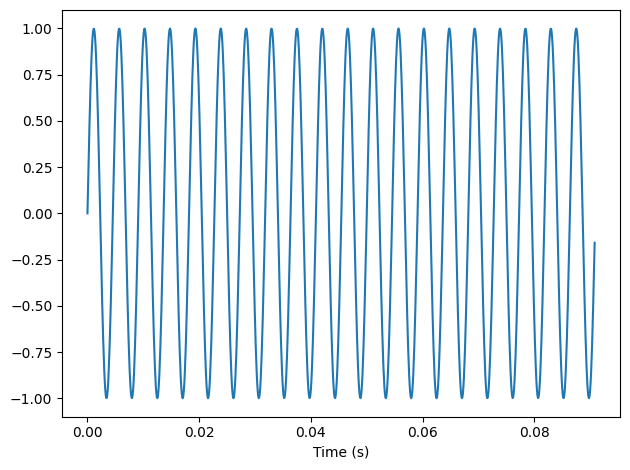

In [7]:
duration_normal = signal.period * 20
wave_normal = signal.make_wave(duration_normal)
wave_normal.plot()
decorate(xlabel='Time (s)')

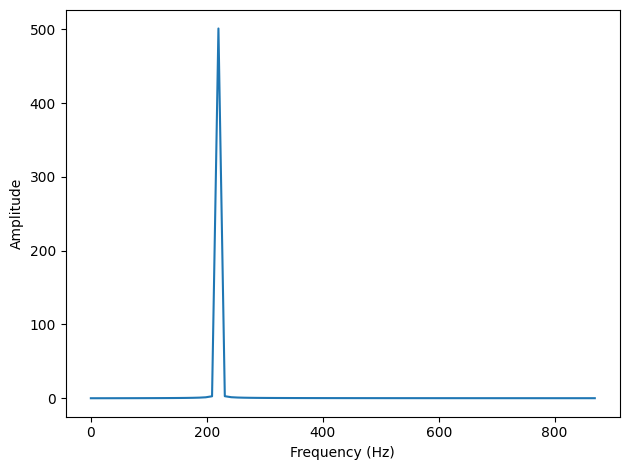

In [8]:
spectrum_normal = wave_normal.make_spectrum()
spectrum_normal.plot(high=880)
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')

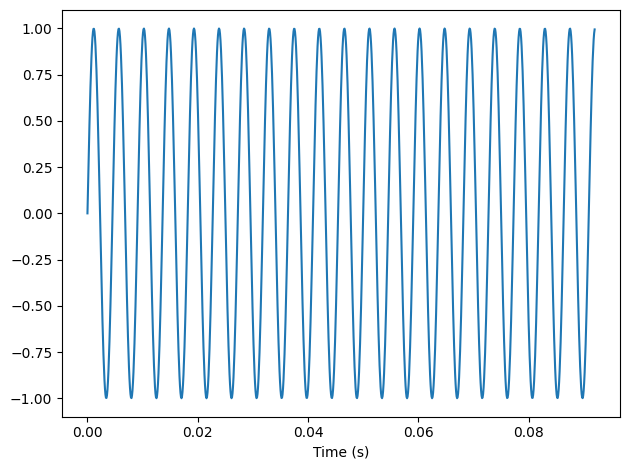

In [9]:
duration_leakage = signal.period * 20.25
wave_leakage = signal.make_wave(duration_leakage)
wave_leakage.plot()
decorate(xlabel='Time (s)')

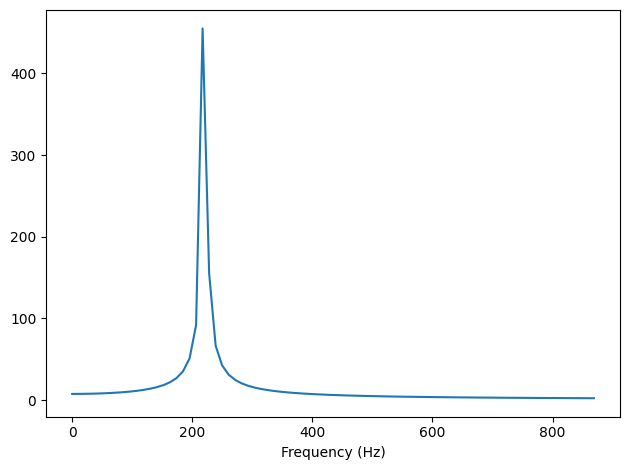

In [11]:
spectrum_leakage = wave_leakage.make_spectrum()
spectrum_leakage.plot(high=880)
decorate(xlabel='Frequency (Hz)')

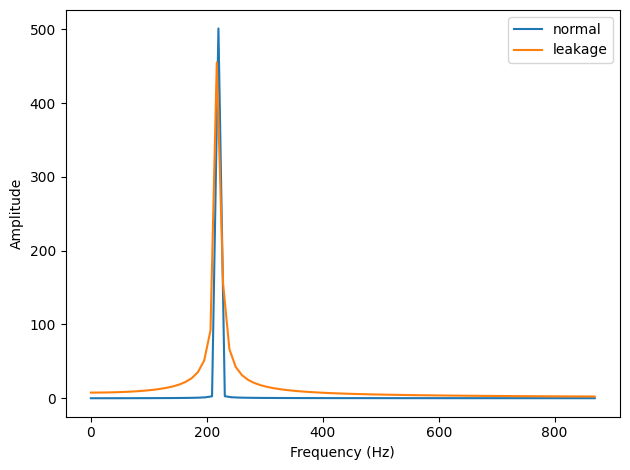

In [12]:
spectrum_normal.plot(high=880, label="normal")
spectrum_leakage.plot(high=880, label="leakage")
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')
plt.legend()

In [13]:
def triangle_window(npoints):
    win_func = np.ones(npoints)
    L = npoints
    for num in range(npoints) :
        win_func[num] = 1 - abs((num - npoints/2)/(L/2))
    return win_func

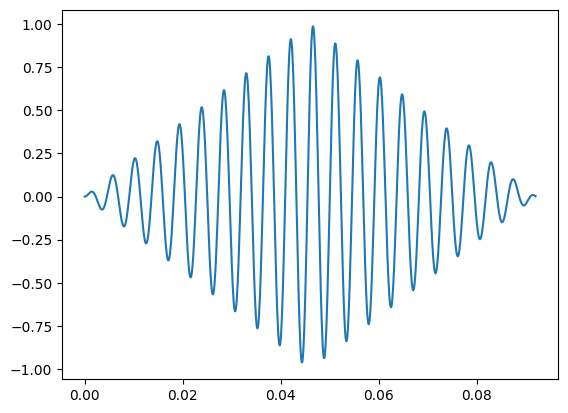

In [14]:
npoints = len(wave_leakage.ys)
win_func = triangle_window(npoints)
wave_n = wave_leakage.copy()
wave_n.window(win_func)
wave_n.plot()

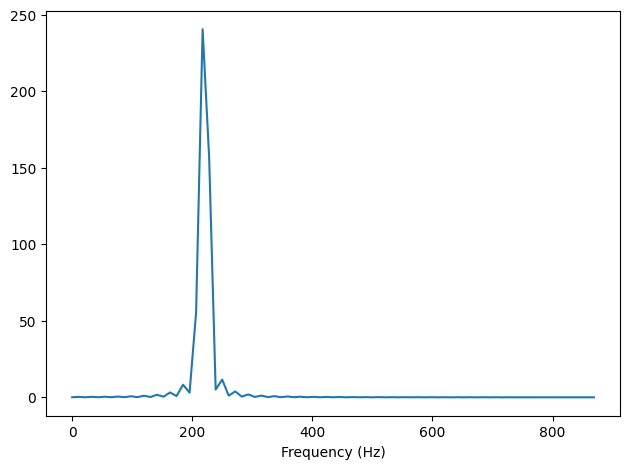

In [15]:
spectrum_w = wave_n.make_spectrum()
spectrum_w.plot(high=880)
decorate(xlabel='Frequency (Hz)')

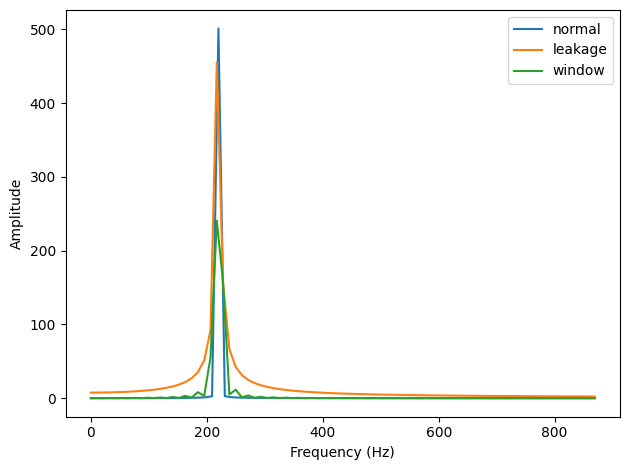

In [16]:
spectrum_normal.plot(high=880, label="normal")
spectrum_leakage.plot(high=880, label="leakage")
spectrum_w.plot(high=880, label="window")
decorate(xlabel='Frequency (Hz)', ylabel='Amplitude')
plt.legend()